In [11]:
import pandas as pd
import numpy as np

spam_data = pd.read_csv('assets/spam.csv')

#spam_data['target'] = np.where(spam_data['target']=='spam',1,0)
spam_data.info()
df = spam_data
df.columns = ["message", "label"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5572 non-null   object
 1   target  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


Text(0.5, 1.0, 'Amount of spam and no spam messages')

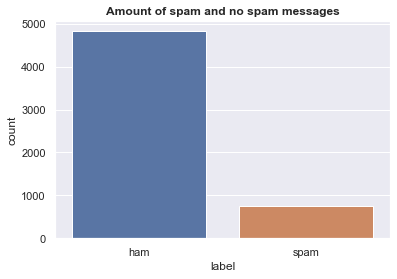

In [13]:
import seaborn as sns

sns.set()

sns.countplot(data = spam_data, x = spam_data['label']).set_title("Amount of spam and no spam messages", fontweight = 'bold')
#plt.show()

Go
Free
1019
[('to', 604), ('a', 358), ('your', 187), ('call', 185), ('or', 185), ('the', 178), ('2', 169), ('for', 169), ('you', 164), ('is', 143), ('Call', 136), ('on', 135), ('have', 128), ('and', 119), ('from', 116), ('ur', 107)]


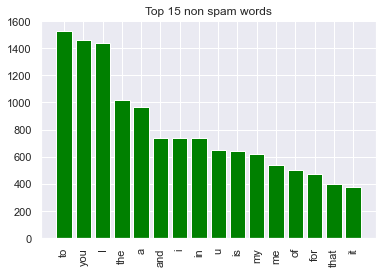

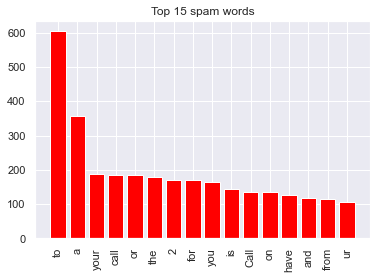

In [27]:
import itertools
from collections import Counter
import matplotlib.pyplot as plt

non_spam_messages = df[df["label"]=="ham"]["message"] #filters non-spam (ham) messages
l = [message.split() for message in non_spam_messages] #creates lists of words from each message
no_spam_words = list(itertools.chain.from_iterable(l)) #concatenates all lists of words into one

print(no_spam_words[0])
spam_messages = df[df["label"]=="spam"]["message"] 
k = [message.split() for message in spam_messages]
spam_words = list(itertools.chain.from_iterable(k))

print(spam_words[0])

non_spam = Counter(no_spam_words) #creates dictionary with occurrences of each no_spam word
spam = Counter(spam_words) #creates dictionary occurences of each spam word (creates dictionary)
print(non_spam['the'])
#print(non_spam)

#print(non_spam.items())

non_spam = sorted(non_spam.items(), key=lambda kv: kv[1], reverse=True) #creates list sorted descending by value (number of occurences) 


spam = sorted(spam.items(), key=lambda kv: kv[1], reverse=True) 
#print(spam['the'])

top15_spam = spam[:16]
top15_nonspam = non_spam[:16]
print(top15_spam)

##slice word and occurences so I can easily plot them
top_words_nonspam = [i[0] for i in top15_nonspam]  #(to,1530) [0]=to [1]=1530  
top_occurences_nonspam = [i[1] for i in top15_nonspam]

top_words_spam = [i[0] for i in top15_spam]       
top_occurences_spam = [i[1] for i in top15_spam]

plt.bar(top_words_nonspam, top_occurences_nonspam, color = 'green')
plt.title("Top 15 non spam words")
plt.xticks(rotation='vertical')
plt.show()

plt.bar(top_words_spam, top_occurences_spam, color = "red")
plt.title("Top 15 spam words")
plt.xticks(rotation='vertical')
plt.show()

In [1]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score
import re

#smoothing is a smoothing technique that helps tackle the problem of zero probability in the Naïve Bayes machine learning algorithm
import nltk
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X_train, y_train)
features_list = vectorizer.get_feature_names()
#sorted_features_list = sorted(features_list, key = lambda val: len(val), reverse = True)
#sorted_features_list[0]

token_list =[]

for row in spam_data['text'].values: 
    #token_list.append(nltk.word_tokenize(row))
    token_list = token_list + nltk.word_tokenize(row)
    #print(token_list)
print(token_list[:10]) 

token_set = set (token_list)

row = 0 
feature_array = []

while row < len(spam_data['text']):
    row_list = []
    for token in token_set: 
        token_list = re.findall(pat = token, spam_data['text'][row])
        row_list.append(len(token_list))
    feature_array.append(row_list)
    row = row+1

print(feature_array[0])

SyntaxError: positional argument follows keyword argument (Temp/ipykernel_15280/3879193062.py, line 31)